 (a) Create a binary variable, mpg01, that contains a 1 if mpg contains
 a value above its median, and a 0 if mpg contains a value below
 its median. You can compute the median using the median()
 method of the data frame. Note you may find it helpful to add
 a column mpg01 to the data frame by assignment. Assuming you
 have stored the data frame as Auto, this can be done as follows:

In [1]:
import pandas as pd

Auto = pd.read_csv("Auto.csv", na_values='?')
Auto = Auto.dropna().reset_index(drop=True)

mpg_median = Auto["mpg"].median()
Auto["mpg01"] = (Auto["mpg"] > mpg_median).astype(int)


 (b) Explore the data graphically in order to investigate the association between mpg01 and the other features. Which of the other
 features seem most likely to be useful in predicting mpg01? Scat
terplots and boxplots may be useful tools to answer this ques
tion. Describe your findings.

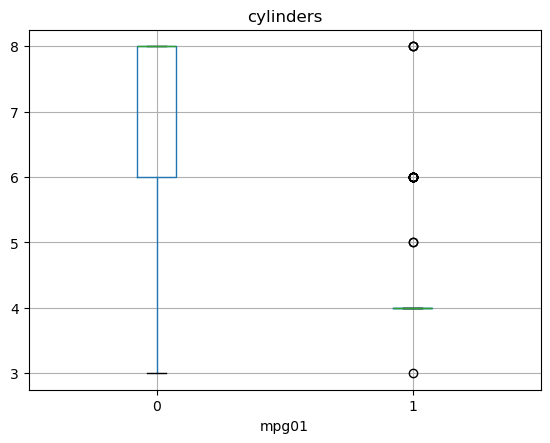

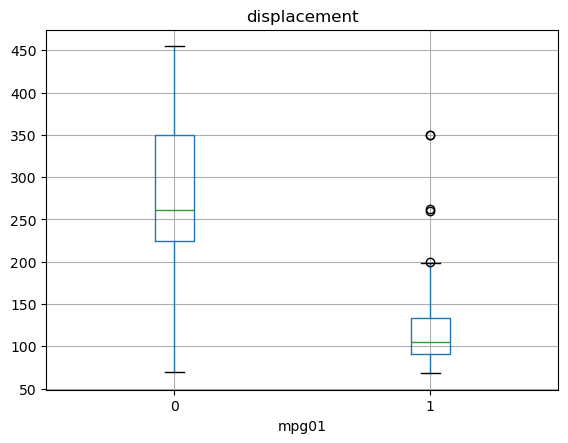

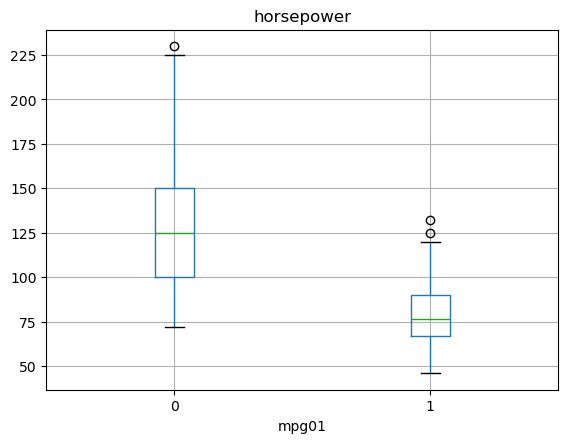

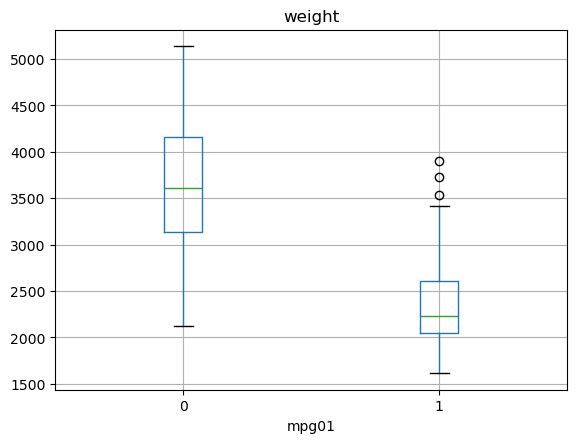

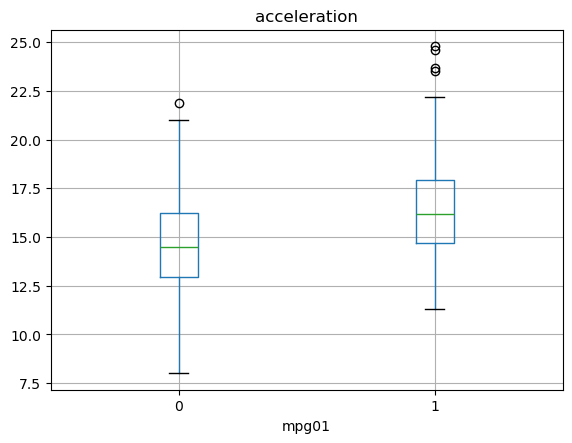

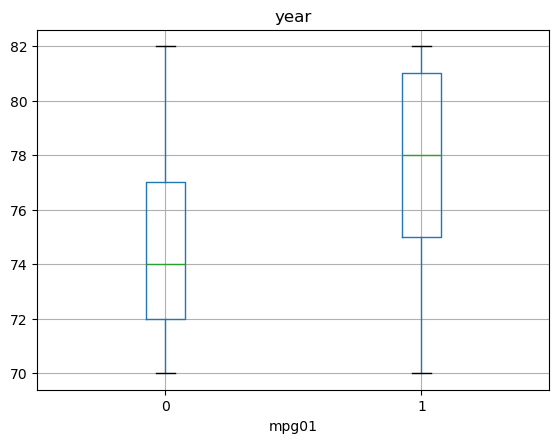

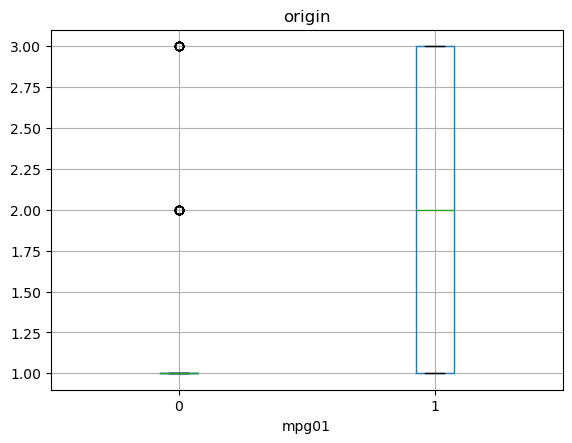

In [2]:
import matplotlib.pyplot as plt

cols = ["cylinders","displacement","horsepower","weight","acceleration","year","origin"]

for c in cols:
    Auto.boxplot(column=c, by="mpg01")
    plt.title(c)
    plt.suptitle("")
    plt.show()


cylinders、displacement、horsepower、weight → 高 mpg（mpg01=1） 時都顯著較低。
→ 負相關（汽缸多、馬力大、重量重 → 油耗高，效率低）。

year → 越新的車，油耗表現越好（正相關）。

acceleration、origin → 也有部分區辨度，但較弱。

 (c) Split the data into a training set and a test set

In [3]:
from sklearn.model_selection import train_test_split

X = Auto[["cylinders","displacement","horsepower","weight","year","origin"]]
y = Auto["mpg01"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)


 (d) Perform LDA on the training data in order to predict mpg01
 using the variables that seemed most associated with mpg01 in
 (b). What is the test error of the model obtained?


In [4]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.metrics import accuracy_score

lda = LinearDiscriminantAnalysis()
lda.fit(X_train, y_train)
pred = lda.predict(X_test)

acc = accuracy_score(y_test, pred)
print("LDA Test Accuracy:", round(acc,4))


LDA Test Accuracy: 0.9237


 (e) Perform QDA on the training data in order to predict mpg01
 using the variables that seemed most associated with mpg01 in
 (b). What is the test error of the model obtained?

In [5]:
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis

qda = QuadraticDiscriminantAnalysis()
qda.fit(X_train, y_train)
pred = qda.predict(X_test)

acc = accuracy_score(y_test, pred)
print("QDA Test Accuracy:", round(acc,4))


QDA Test Accuracy: 0.9153


 (f) Perform logistic regression on the training data in order to pre
dict mpg01 using the variables that seemed most associated with
 mpg01 in (b). What is the test error of the model obtained?

In [6]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

logit = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(max_iter=200))
])
logit.fit(X_train, y_train)
pred = logit.predict(X_test)

acc = accuracy_score(y_test, pred)
print("Logistic Regression Accuracy:", round(acc,4))


Logistic Regression Accuracy: 0.9237


 (g) Perform naive Bayes on the training data in order to predict
 mpg01 using the variables that seemed most associated with mpg01
 in (b). What is the test error of the model obtained?

In [7]:
from sklearn.naive_bayes import GaussianNB

nb = GaussianNB()
nb.fit(X_train, y_train)
pred = nb.predict(X_test)

acc = accuracy_score(y_test, pred)
print("Naive Bayes Accuracy:", round(acc,4))


Naive Bayes Accuracy: 0.9068


 (h) Perform KNN on the training data, with several values of K, in
 order to predict mpg01. Use only the variables that seemed most
 associated with mpg01 in (b). What test errors do you obtain?
 Which value of K seems to perform the best on this data set?

In [8]:
from sklearn.neighbors import KNeighborsClassifier

errors = []
for k in range(1, 31):
    knn = Pipeline([
        ("scaler", StandardScaler()),
        ("clf", KNeighborsClassifier(n_neighbors=k))
    ])
    knn.fit(X_train, y_train)
    acc = knn.score(X_test, y_test)
    errors.append((k, 1-acc))

errors_df = pd.DataFrame(errors, columns=["k","test_error"])
print(errors_df.sort_values("test_error").head())


     k  test_error
3    4    0.059322
2    3    0.067797
29  30    0.076271
28  29    0.076271
20  21    0.076271
